In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sbibm

from pyro_cases.run import train_and_test

In [3]:
device = torch.device("cuda:1")

In [4]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [5]:
# torch.autograd.set_detect_anomaly(True)

In [ ]:
out_dict = train_and_test(task_name="arm_latent_glm",
                          seed=123456,
                          device=device,
                          lr=1e-3,
                          lr_schedule="cosine_annealing",
                          num_particles=1,
                          vectorize_particles=False,
                          batch_size=1024,
                          network_width=2048,
                          steps=10_000,
                          direct_compare_n_obs=10,
                          k_hat_n_obs=30,
                          k_hat_n_samples=100,
                          vsbc_n_obs=1000,
                          show_progress=True,
                          return_vae=True,
                          suppress_error=False)

100%|██████████| 10000/10000 [10:33<00:00, 15.78it/s]
/home/pduan/gcvi_neurips_additional_exp/pyro_cases/psis.py:281: RuntimeWarning: divide by zero encountered in divide
  bs /= PRIOR * x[sort[int(n/4 + 0.5) - 1]]
/home/pduan/gcvi_neurips_additional_exp/pyro_cases/psis.py:285: RuntimeWarning: invalid value encountered in multiply
  temp = ks[:,None] * x
/home/pduan/gcvi_neurips_additional_exp/pyro_cases/psis.py:322: RuntimeWarning: invalid value encountered in scalar divide
  sigma = -k / b * n / (n - 0)


[123456 completes] task start time: Sun Mar 30 19:57:44 2025; task end time: Sun Mar 30 20:11:21 2025; cost time: 817.3 seconds


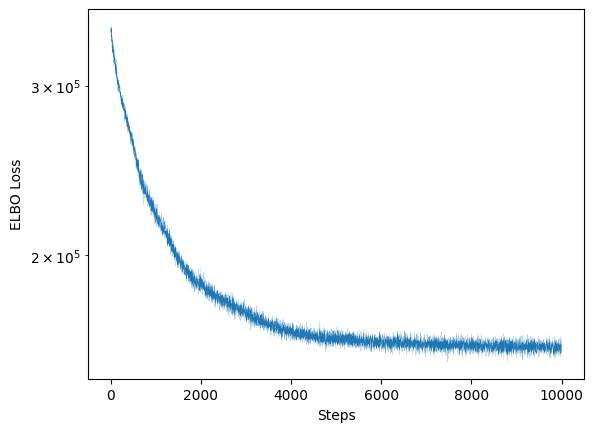

In [7]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("log")
plt.show()

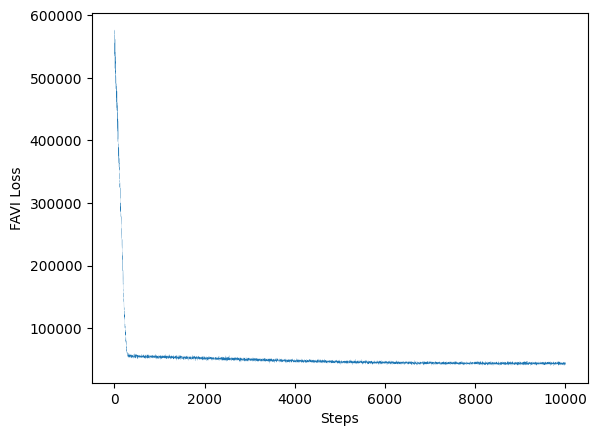

In [8]:
plt.plot(out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
# plt.yscale("log")
plt.show()

### K hat

In [9]:
print(out_dict["favi_k_hat"])
print(out_dict["elbo_k_hat"])

tensor([0.1667, 1.1567, 1.4159, 1.0056, 1.4458, 0.1667, 1.9656, 1.3985, 0.1667,
        5.3081, 1.6029, 1.6945, 1.1321, 1.1726, 1.0433, 7.6066, 2.9033, 1.4373,
        1.3037, 0.1667, 1.2795, 1.7003, 1.7969, 1.9092, 1.2342, 1.2131, 0.7389,
        0.6725, 0.1667, 1.7655], dtype=torch.float64)
tensor([4.3119, 1.7683, 3.0261, 1.6124, 4.0845, 4.9275, 6.7664, 4.4378, 2.3651,
        4.0796, 6.1459, 1.3101, 1.9905, 1.9685, 3.7934, 2.5449, 3.1973, 1.7541,
        4.6230, 2.4838, 1.9911, 4.0572, 3.7077, 2.7718, 4.5161, 1.3135, 3.4582,
        1.0192, 3.6261, 1.5201], dtype=torch.float64)


In [10]:
print(out_dict["favi_k_hat"].mean())
print(out_dict["elbo_k_hat"].mean())

tensor(1.5579, dtype=torch.float64)
tensor(3.1724, dtype=torch.float64)


### VSBC

In [11]:
favi_vsbc = out_dict["favi_vsbc"]
elbo_vsbc = out_dict["elbo_vsbc"]

In [12]:
def plot_vsbc(vsbc_matrix: torch.Tensor):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.tight_layout()
    fig.show()

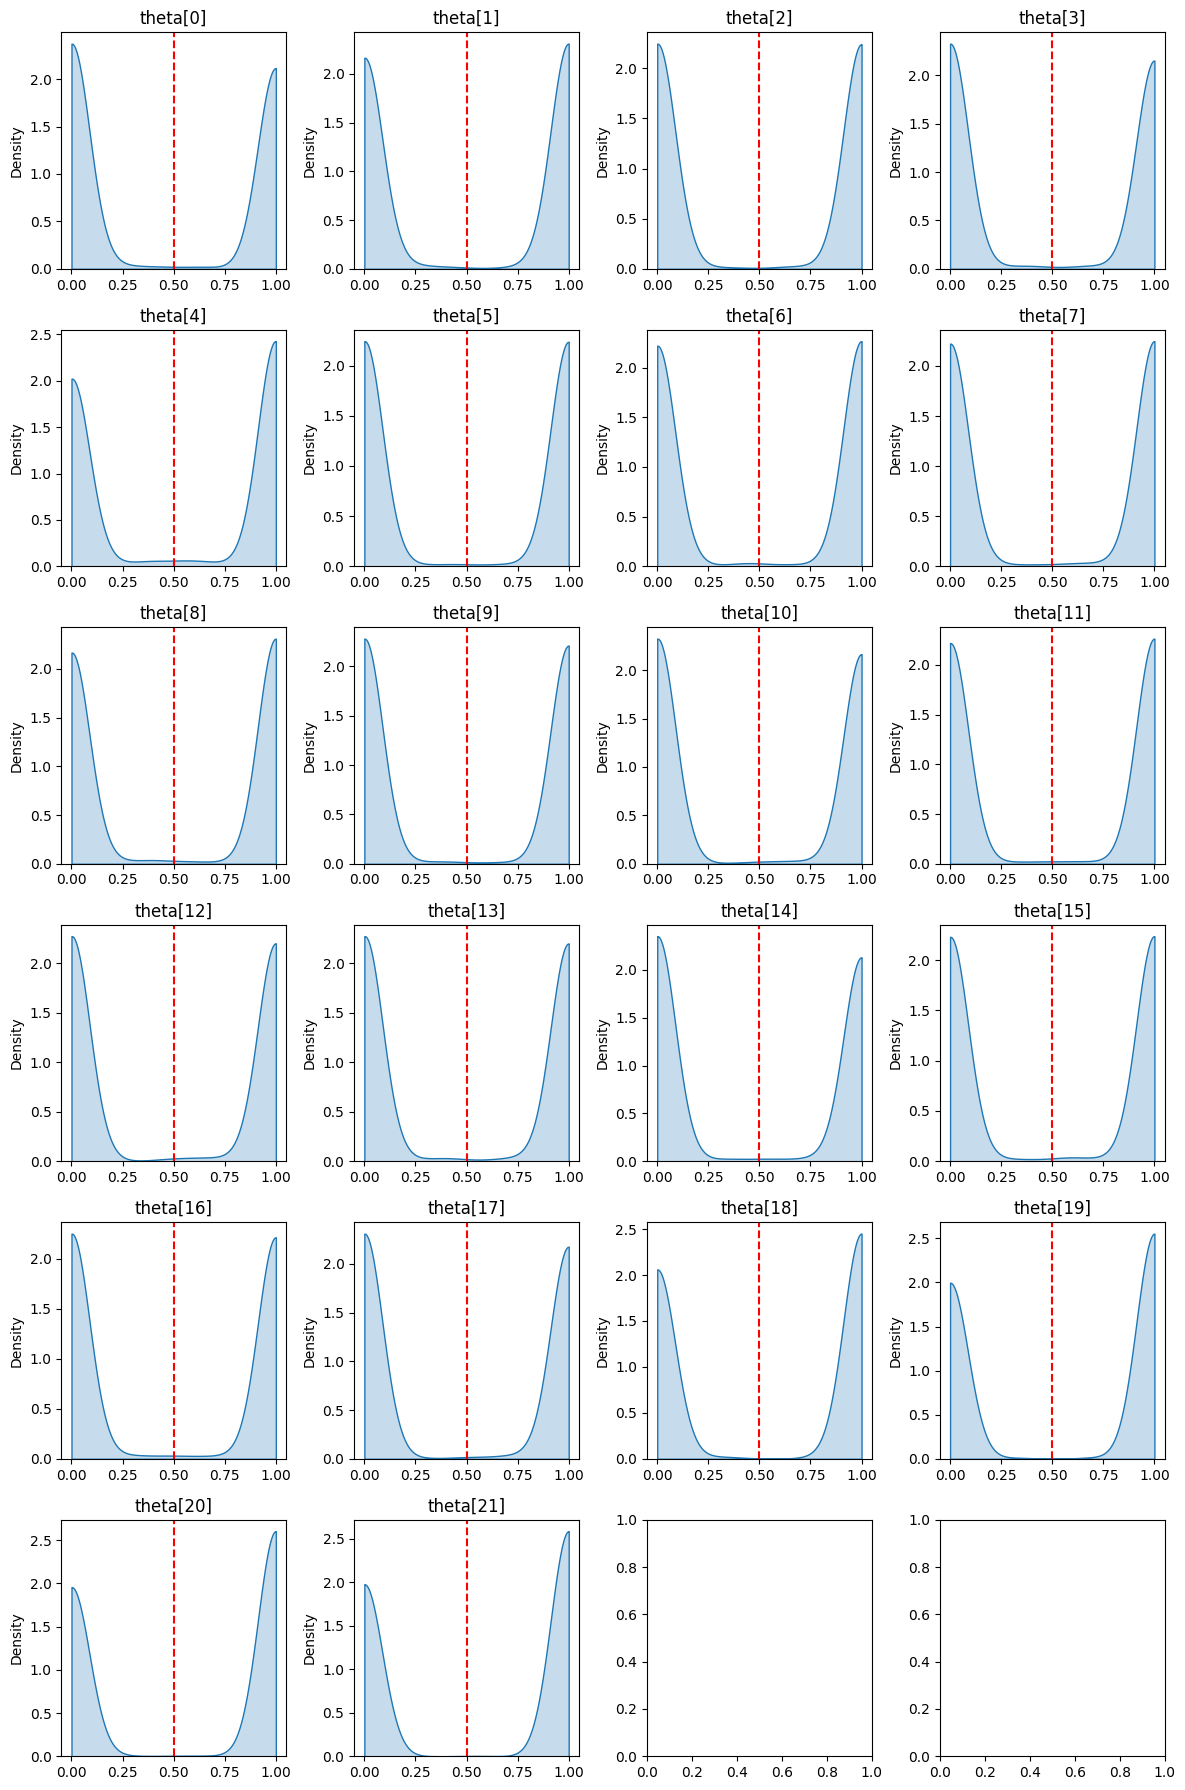

In [13]:
plot_vsbc(favi_vsbc)

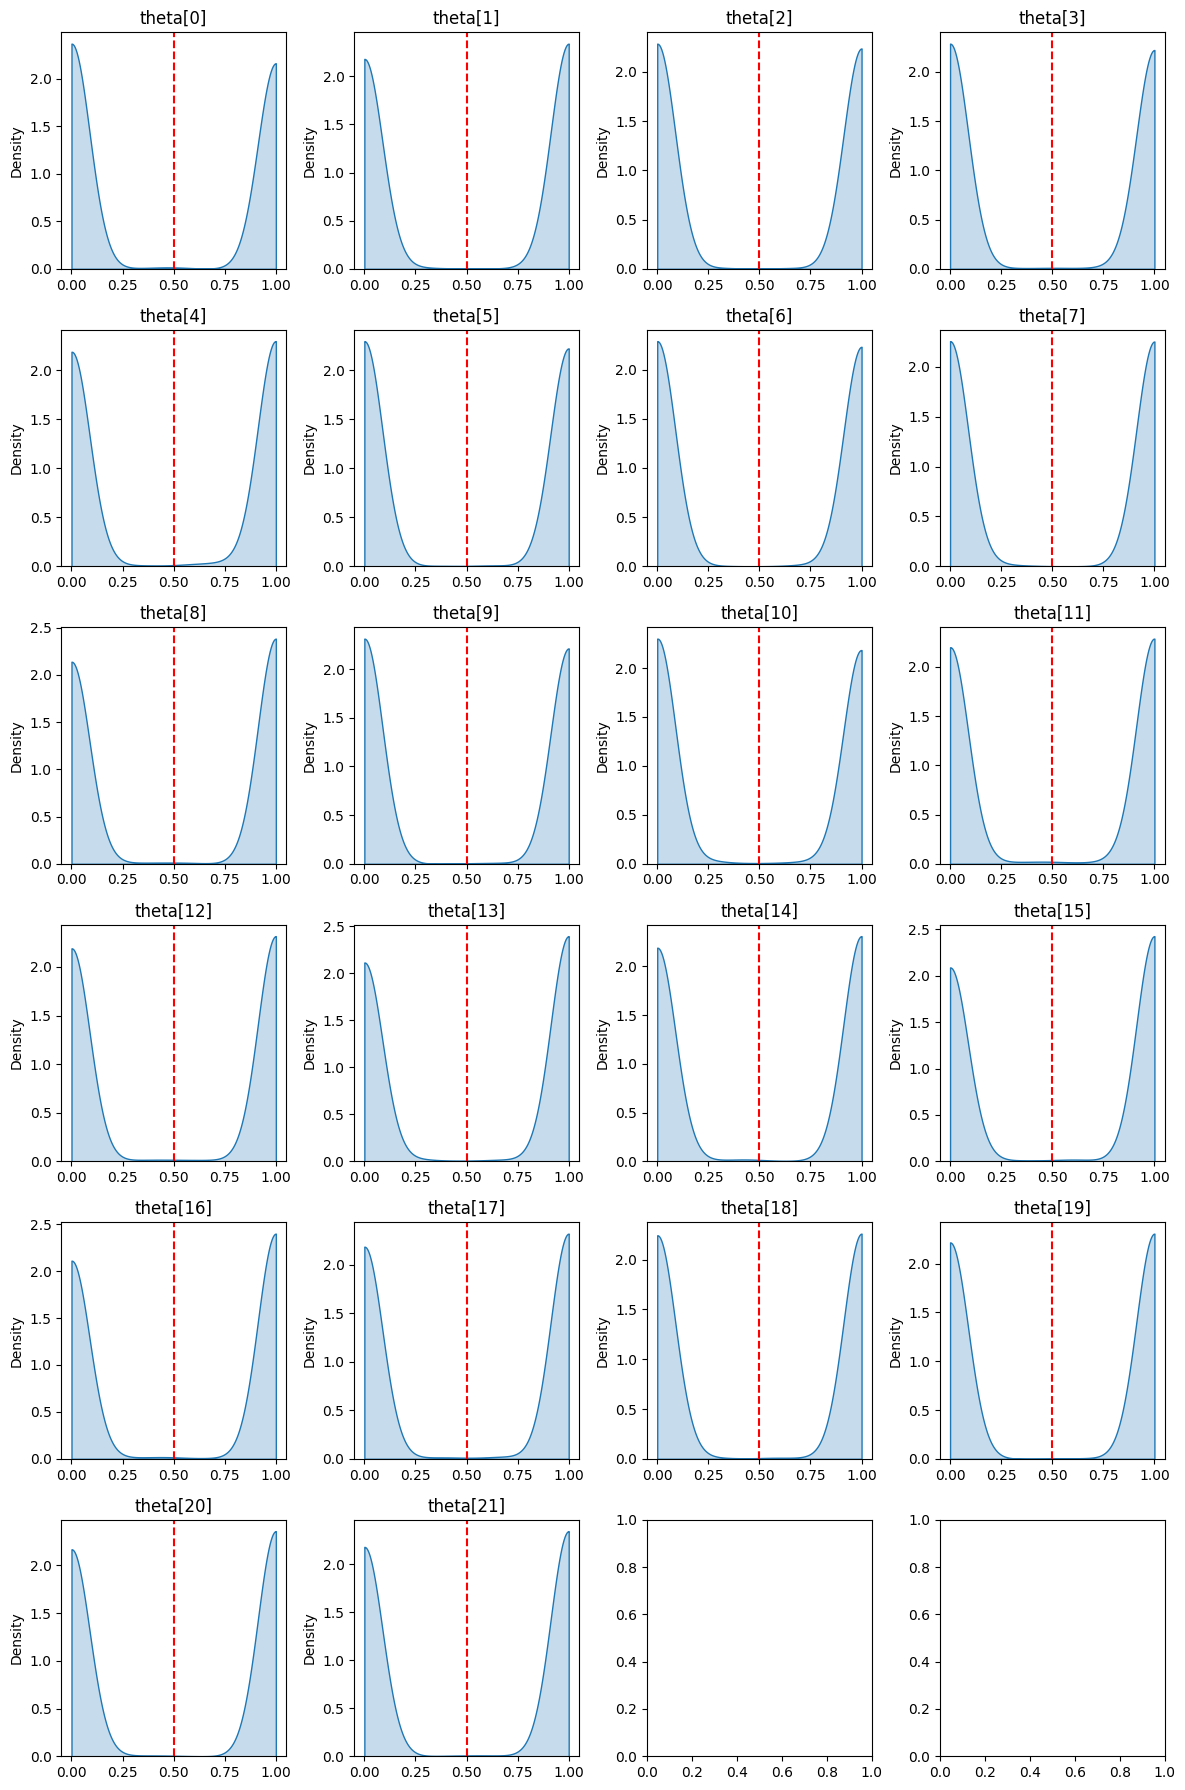

In [14]:
plot_vsbc(elbo_vsbc)

### Output

In [15]:
out_dict["elbo_test_dict_list"][0]["obs_seed"]

10000

In [16]:
out_dict["elbo_test_dict_list"][0]["obs"]

tensor([[1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.,
         0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
         1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
         1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1.,
         0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1.,
         0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.,
         0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
         0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
         1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1.,
         1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
         1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1.,
         1., 0., 1., 0., 0.,

In [17]:
out_dict["elbo_test_dict_list"][0]["true_theta"]

tensor([  99.0392,  -69.9826,   33.7718,  154.0505, -124.8526,  -42.6005,
          87.1256,   29.9420,   11.7374, -118.5464,  315.4961,  -18.4603,
         -43.5437,  164.5366,  -44.1933,  -53.6947,   86.4890,   37.6087,
         158.5410, -138.2869, -389.0479, -336.3762])

In [18]:
out_dict["elbo_test_dict_list"][0]["est_mu"]

tensor([-0.1565,  0.0362,  0.0402,  0.7018, -2.2575, -1.7320, -1.5916, -1.4828,
        -0.8790, -1.2330,  1.4053, -1.4965,  4.5658,  4.4413,  4.9398,  4.0449,
         6.1853,  4.3078,  0.2024, -2.2774, -9.7590, -8.8282])

In [19]:
out_dict["elbo_test_dict_list"][0]["est_sigma2"]

tensor([0.0873, 0.1893, 0.1894, 0.6683, 5.0000, 0.4266, 0.4038, 0.3812, 0.2386,
        0.2980, 5.0000, 5.0000, 0.9271, 0.9252, 1.0079, 0.8578, 1.1997, 0.8920,
        0.5352, 1.0453, 3.0999, 3.0267])

In [20]:
out_dict["favi_test_dict_list"][0]["obs_seed"]

10000

In [21]:
out_dict["favi_test_dict_list"][0]["obs"]

tensor([[1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.,
         0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
         1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
         1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1.,
         0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1.,
         0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.,
         0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
         0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
         1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1.,
         1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
         1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1.,
         1., 0., 1., 0., 0.,

In [22]:
out_dict["favi_test_dict_list"][0]["true_theta"]

tensor([  99.0392,  -69.9826,   33.7718,  154.0505, -124.8526,  -42.6005,
          87.1256,   29.9420,   11.7374, -118.5464,  315.4961,  -18.4603,
         -43.5437,  164.5366,  -44.1933,  -53.6947,   86.4890,   37.6087,
         158.5410, -138.2869, -389.0479, -336.3762])

In [23]:
out_dict["favi_test_dict_list"][0]["est_mu"]

tensor([ -3.5862,   2.2214,   2.4772,   2.0902, -46.9136,  -1.3195,   0.2007,
          1.4257,   5.6518,  -7.5564,  12.4276, -19.6433,   1.4400,  -2.7411,
          2.9175,  -3.3586,   4.5104,  -1.1415, -26.3538, -29.0792, -27.8213,
        -19.1736])

In [24]:
out_dict["favi_test_dict_list"][0]["est_sigma2"]

tensor([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5.])